In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

## Load Dataset

In [3]:
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

print("First 5 Rows")
display(df.head())

print("Dataset Shape:", df.shape)

First 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Shape: (7043, 21)


## Data Understanding

In [4]:
print("\nColumn Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

## Data Cleaning

In [5]:
# Convert 'TotalCharges' to numeric (handle empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

## Encode Categorical Columns

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    if col != "Churn":
        df[col] = le.fit_transform(df[col])

# Target column encode
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

print("\nCleaned Data")
display(df.head())


Cleaned Data


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


## Exploratory Data Analysis

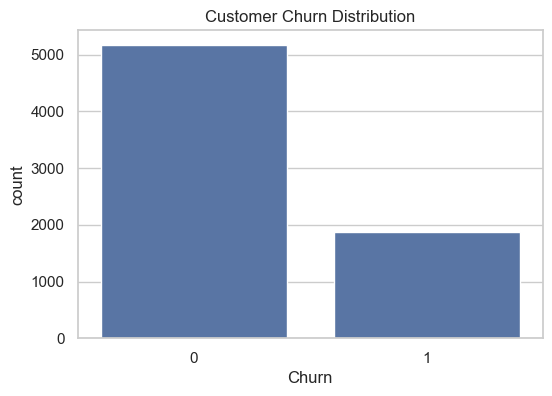

In [7]:
# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

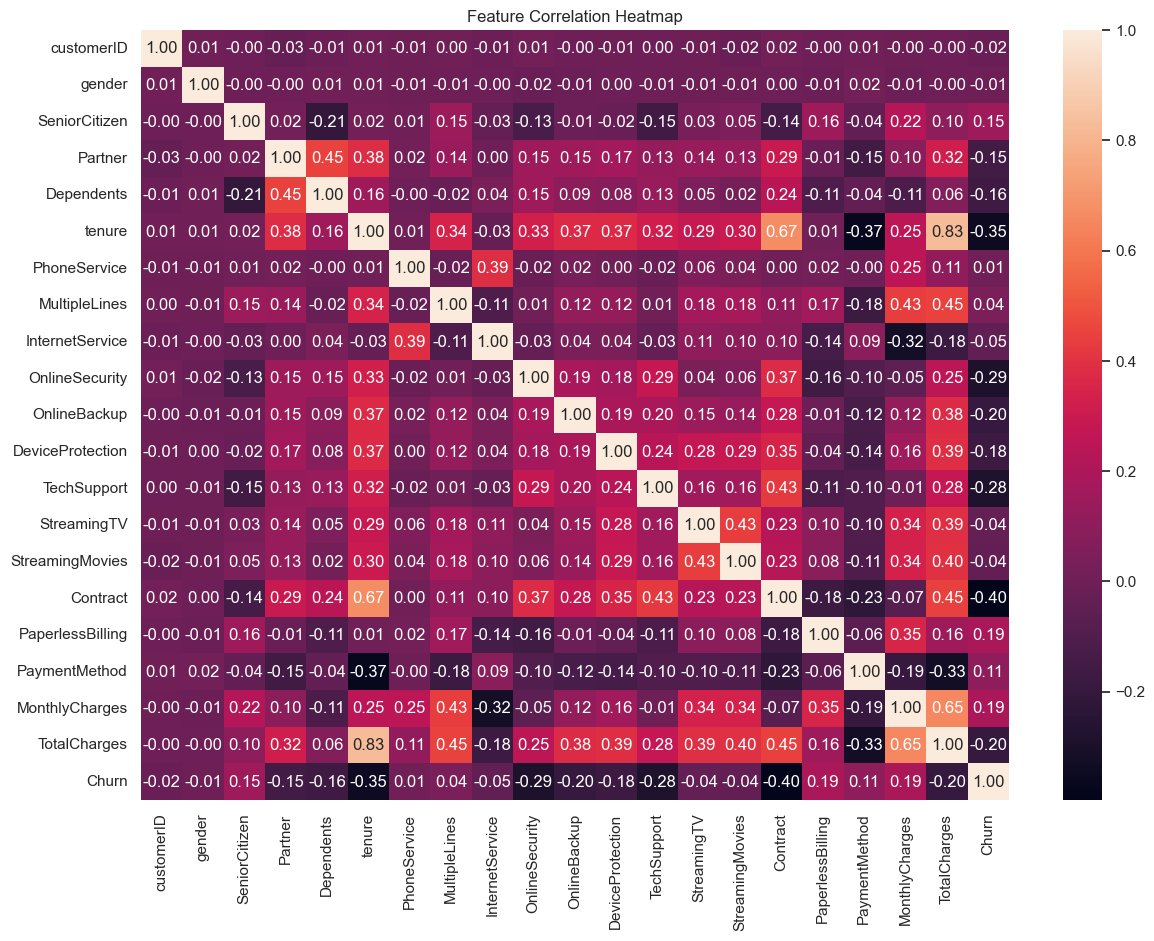

In [8]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## Customer Segmentation

In [9]:
seg_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_seg = df[seg_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)
kmeans = KMeans(n_clusters=4, random_state=42)
df["Segment"] = kmeans.fit_predict(X_scaled)

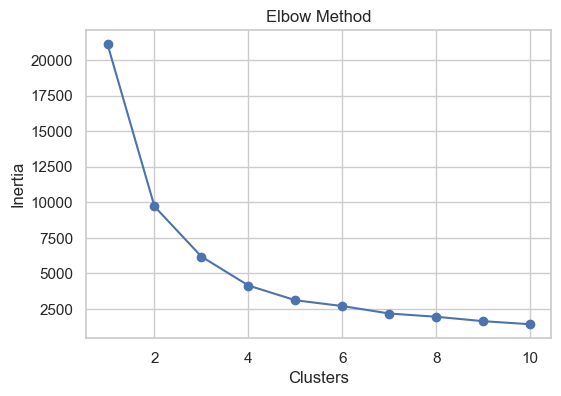

In [10]:
# Elbow Method
inertia = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

#### Final Model

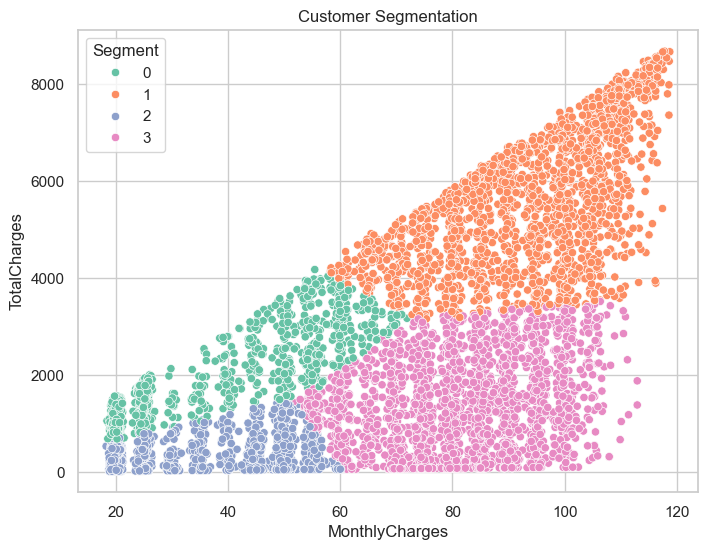

In [11]:
# Final Model
# Segment Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Segment",
    data=df,
    palette="Set2"
)
plt.title("Customer Segmentation")
plt.show()

##### Prepare Data for ML

In [12]:
X = df.drop(["customerID", "Churn", "Segment"], axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale for Logistic Regression
scaler2 = StandardScaler()

X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

#### Logistic Regression

Logistic Regression Accuracy: 0.815471965933286
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



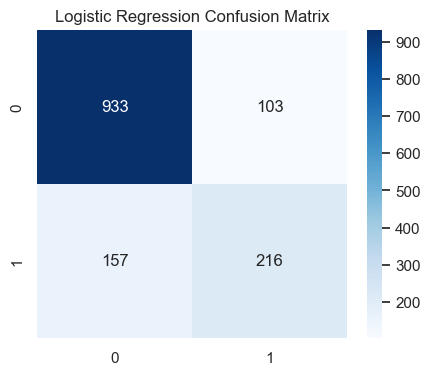

In [13]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred_lr))

print(classification_report(y_test, pred_lr))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, pred_lr),
            annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#### Random Forest

Random Forest Accuracy: 0.7955997161107168
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



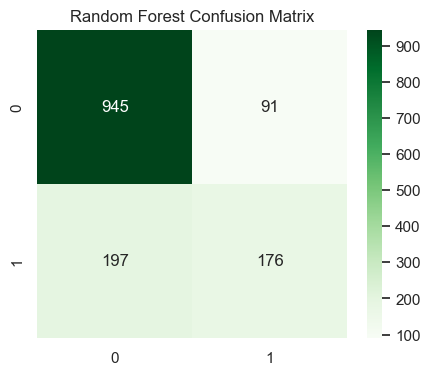

In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, pred_rf))

print(classification_report(y_test, pred_rf))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, pred_rf),
            annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

#### Hyperparameter Tuning

In [15]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[None,5,10],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

pred_tuned = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:",accuracy_score(y_test, pred_tuned))

Tuned Random Forest Accuracy: 0.8034066713981547


#### Model Comparison

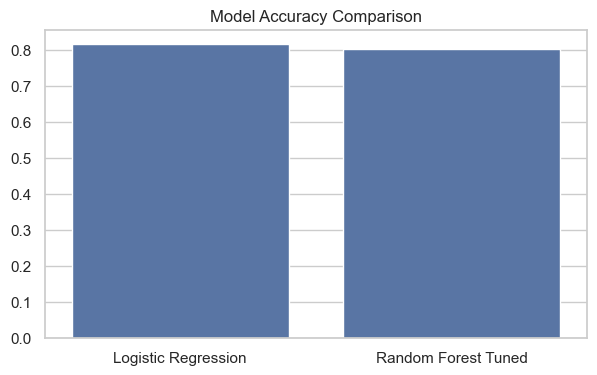

In [16]:
models = [
    "Logistic Regression",
    # "Random Forest",
    "Random Forest Tuned"
]

scores = [
    accuracy_score(y_test, pred_lr),
    # accuracy_score(y_test, pred_rf),
    accuracy_score(y_test, pred_tuned)
]

plt.figure(figsize=(7,4))
sns.barplot(x=models, y=scores)
plt.title("Model Accuracy Comparison")
# plt.ylim(0.70,1.00)
plt.show()

#### Feature Importance

             Feature  Importance
4             tenure    0.161325
18      TotalCharges    0.157078
17    MonthlyCharges    0.142629
14          Contract    0.129562
8     OnlineSecurity    0.076451
11       TechSupport    0.055759
16     PaymentMethod    0.043048
7    InternetService    0.041455
9       OnlineBackup    0.028724
15  PaperlessBilling    0.023136
6      MultipleLines    0.020717
10  DeviceProtection    0.020563
0             gender    0.017288
13   StreamingMovies    0.015972
3         Dependents    0.015380
2            Partner    0.015330
1      SeniorCitizen    0.015206
12       StreamingTV    0.014482
5       PhoneService    0.005894


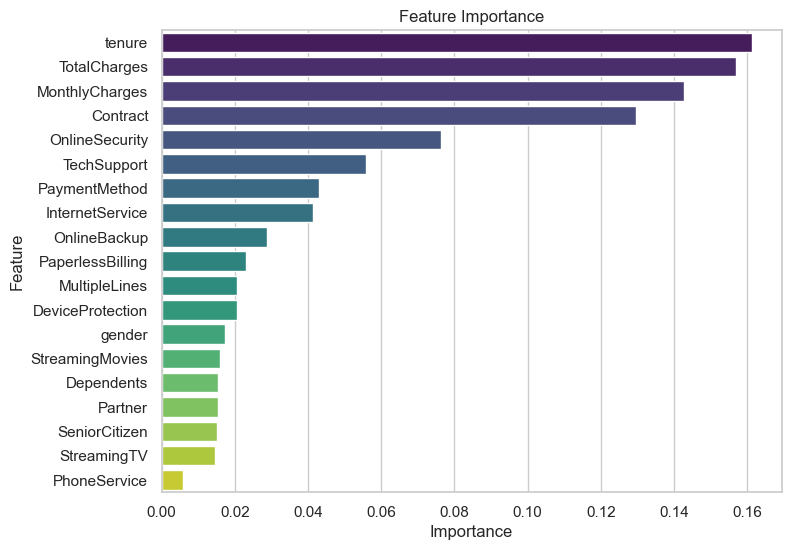

In [17]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_imp,
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title("Feature Importance")
plt.show()

#### Business Metrics

In [18]:
# Customer Lifetime Value
df["CLV"] = df["MonthlyCharges"] * df["tenure"]

# Overall Churn Rate
overall_churn = round(df["Churn"].mean()*100,2)

print("Overall Churn Rate:", overall_churn,"%")

# Revenue Lost Approximation
churned = df[df["Churn"] == 1]

revenue_lost = (churned["MonthlyCharges"] * churned["tenure"]).sum()

print("Estimated Revenue Lost:", round(revenue_lost,2))

Overall Churn Rate: 26.54 %
Estimated Revenue Lost: 2862576.9


In [19]:
#Export Final File
df.to_csv("Final_Telco_Churn_Data.csv", index=False)

feat_imp.to_csv("Feature_Importance.csv", index=False)

print("\nFiles Exported Successfully!")
print("1. Final_Telco_Churn_Data.csv")
print("2. Feature_Importance.csv")


Files Exported Successfully!
1. Final_Telco_Churn_Data.csv
2. Feature_Importance.csv
